In [3]:
import sounddevice as sd

print(sd.query_devices())
print(sd.query_hostapis())

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Analogue 1 + 2 (8- Focusrite US, MME (8 in, 0 out)
   2 Microphone Array (Intel® Smart , MME (4 in, 0 out)
   3 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  4 Realtek HD Audio 2nd output (Re, MME (0 in, 2 out)
   5 Speakers (Realtek(R) Audio), MME (0 in, 2 out)
   6 Speakers (8- Focusrite USB Audi, MME (0 in, 8 out)
   7 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   8 Analogue 1 + 2 (8- Focusrite USB Audio), Windows DirectSound (8 in, 0 out)
   9 Microphone Array (Intel® Smart Sound Technology (Intel® SST)), Windows DirectSound (4 in, 0 out)
  10 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
  11 Realtek HD Audio 2nd output (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  12 Speakers (Realtek(R) Audio), Windows DirectSound (0 in, 2 out)
  13 Speakers (8- Focusrite USB Audio), Windows DirectSound (0 in, 8 out)
  14 Speakers (Realtek(R) Audio), Windows WASAPI (0 in, 2 out)
  15 Real

In [1]:
import soundfile as sf
from src.audio_device import AudioDevice

In [2]:
arthur, fs = sf.read('data/arthur_clip_48k.wav')
ad = AudioDevice(in_device=1, out_device=4)


<class 'int'> <class 'int'>


In [3]:
len(arthur) / fs

4.975708333333333

In [4]:
ad.play(left=arthur)

(array([ 0.0000000e+00, -3.0517578e-05,  0.0000000e+00, ...,
        -6.1035156e-04, -6.1035156e-04, -6.4086914e-04],
       shape=(238834,), dtype=float32),
 array([ 0.        ,  0.        ,  0.        , ..., -0.00601196,
        -0.00610352, -0.00616455], shape=(238834,), dtype=float32))

In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
click = np.zeros(fs, dtype=np.float32)
click[100] = 1.0

## Both cores, size 32

In [21]:
error_mic, ref_mic = ad.play(left=click)

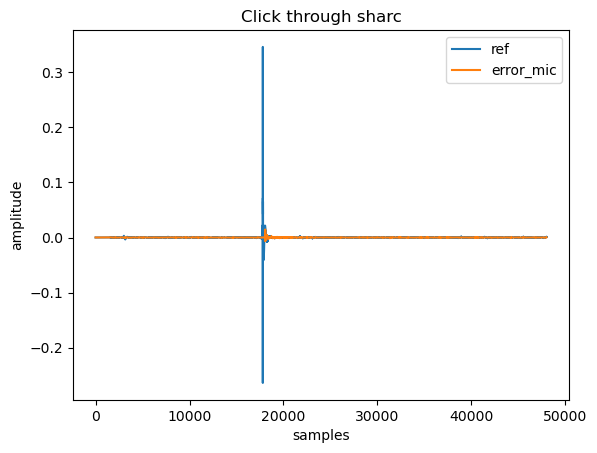

In [22]:
plt.plot(ref_mic, label='ref')
plt.plot(error_mic, label='error_mic')

plt.xlabel('samples')
plt.ylabel('amplitude')
plt.title('Click through sharc')
plt.legend()
plt.show()

In [23]:
ref = ref_mic - np.mean(ref_mic)
err = error_mic - np.mean(error_mic)

corr = np.correlate(err, ref, mode="full")

lag = np.argmax(np.abs(corr)) - (len(ref) - 1)

print(f"Delay: {lag} samples")
print(f"Delay: {1000*lag/48000:.3f} ms")

Delay: 258 samples
Delay: 5.375 ms


In [60]:
def click_measure():
    error_mic, ref_mic = ad.play(left=click)


    ref_idx = np.argmax(np.abs(ref_mic))
    err_idx = np.argmax(np.abs(error_mic))

    delay_samples = err_idx - ref_idx
    delay_ms = 1000 * delay_samples / 48_000

    print(f"Relative delay: {delay_samples} samples")
    print(f"Relative delay: {delay_ms:.3f} ms")

    plt.plot(ref_mic, label='ref')
    plt.plot(error_mic, label='error_mic')

    plt.xlabel('samples')
    plt.ylabel('amplitude')
    plt.title('Click through sharc')
    plt.legend()
    plt.show()

## 2 cores size 32

Relative delay: 258 samples
Relative delay: 5.375 ms


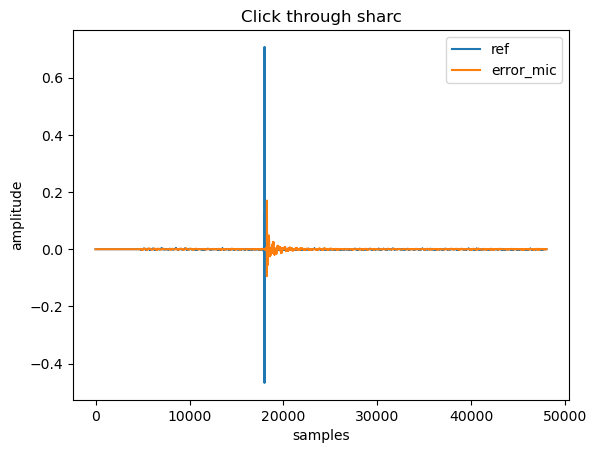

In [119]:
click_measure()

## 2 cores size 16

Relative delay: 179 samples
Relative delay: 3.729 ms


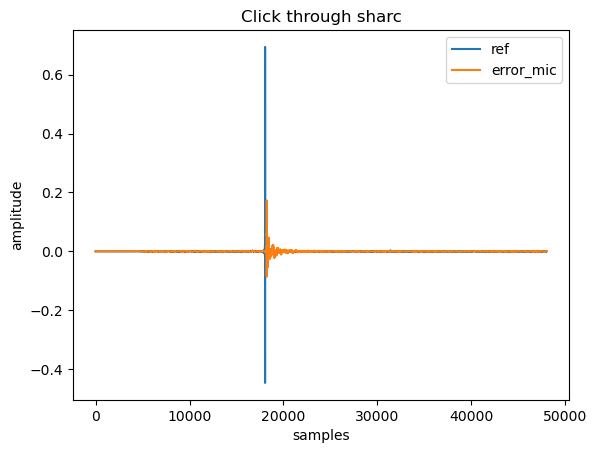

In [116]:
click_measure()

## 2 cores size 8

Relative delay: 138 samples
Relative delay: 2.875 ms


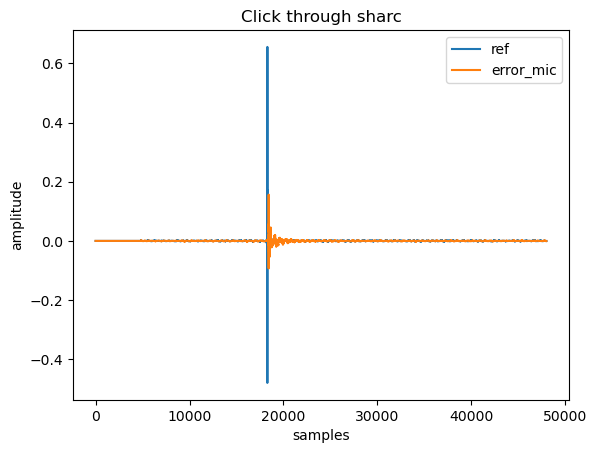

In [113]:
click_measure()

## 1 Core size 32

Relative delay: 193 samples
Relative delay: 4.021 ms


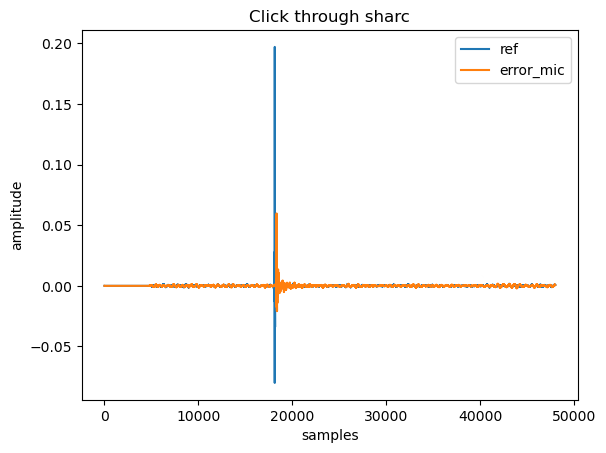

In [106]:
click_measure()

## 1 core size 16

Relative delay: 146 samples
Relative delay: 3.042 ms


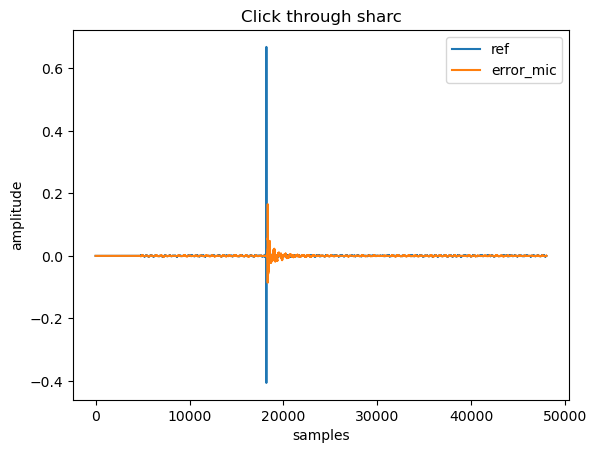

In [108]:
click_measure()

## 1 core size 8

Relative delay: 122 samples
Relative delay: 2.542 ms


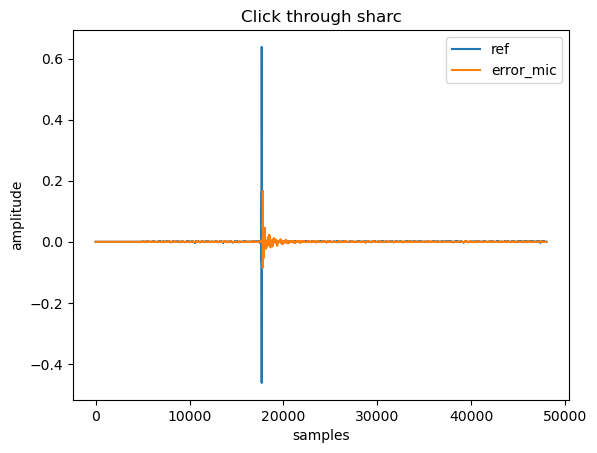

In [111]:
click_measure()